# Equity Factor Tearsheet

A one-page factor attribution report for any ticker. Fama-French 3-factor and
5-factor regressions with Newey-West standard errors and a bootstrapped
confidence interval on alpha.

The question it answers: is this manager or stock earning excess return, or
just renting factor exposure you could buy for 3 basis points?

Section 10 runs the engine on synthetic data with known betas and asserts it
recovers them before anything touches live prices.

**Data:** Yahoo Finance (prices), Ken French Data Library (factors), FRED
(optional risk-free).
**Stack:** numpy, pandas, statsmodels, scipy, matplotlib, yfinance,
pandas_datareader.

## Running it

Run all cells, then edit the ticker in section 11:

```python
generate_tearsheet("AAPL")
compare(["AAPL", "KO", "ARKK", "BRK-B"])
```

## A note on returns

Regressions use simple, not log, returns. The Ken French factors are simple
returns, and mixing the two biases the betas.

## 1. Setup

Colab has numpy, pandas, statsmodels, scipy and matplotlib already. Only the
two data readers need installing.

In [100]:
!pip install -q yfinance pandas_datareader
!pip install -q jinja2

## 2. Imports and configuration

Every parameter that might reasonably change lives in `Config`: date range,
benchmark, bootstrap settings, risk-free source. Change it there, not inline.

In [101]:
from __future__ import annotations

import warnings
from dataclasses import dataclass, field
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
import statsmodels.api as sm
from scipy.stats import norm
import yfinance as yf
import pandas_datareader.data as web
from IPython.display import display

# yfinance and pandas are noisy about deprecations. Narrow, not blanket:
# a bare filterwarnings("ignore") also swallows the low-sample-size warning
# fetch_prices raises, which is the one warning here worth reading.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

TRADING_DAYS = 252


@dataclass
class Config:
    start: str = "2015-01-01"
    end: str = field(default_factory=lambda: datetime.today().strftime("%Y-%m-%d"))
    benchmark: str = "SPY"
    rolling_window: int = 90      # trading days, for the rolling Sharpe panel
    rf_source: str = "kenfrench"  # "kenfrench" or "fred"
    n_boot: int = 1000
    block_size: int = 5           # 1 = iid bootstrap, >1 = moving block
    ci_level: float = 0.95
    seed: int = 42

CFG = Config()

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#cccccc",
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.color":        "#e6e6e6",
    "grid.linewidth":    0.7,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "legend.frameon":    False,
    "figure.dpi":        110,
})

PALETTE = {
    "asset":   "#1f4e79",
    "bench":   "#9aa5b1",
    "good":    "#2e7d32",
    "bad":     "#c0392b",
    "neutral": "#34495e",
}

pct = FuncFormatter(lambda x, _: f"{x:.0f}%")

## 3. Data collection

Three fetchers, one per source.

**Prices** come from Yahoo with `auto_adjust=True`, so splits and dividends
are already in the series.

**Factors** come from the Ken French Data Library, daily FF3 and FF5. The two
sets are kept separate rather than merged: SMB is constructed differently in
each, so the FF3 SMB and the FF5 SMB are not the same series.

**Risk-free** defaults to Ken French's own `RF` column, which is already on
the factor calendar. FRED's 3-month bill is available via `rf_source="fred"`
but arrives on a different calendar and needs de-annualizing.

In [102]:
def fetch_prices(ticker: str, start: str, end: str) -> pd.Series:
    """Split- and dividend-adjusted daily closes for one ticker."""
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if df is None or df.empty:
        raise ValueError(
            f"No price data for '{ticker}'. Check the symbol "
            "(Yahoo uses 'BRK-B', not 'BRK.B') and the date range."
        )
    close = df["Close"]
    if isinstance(close, pd.DataFrame):   # yfinance returns MultiIndex columns
        close = close.iloc[:, 0]          # in some versions, a flat Index in others
    close = close.dropna().astype(float)
    close.name = ticker
    if len(close) < 60:
        warnings.warn(f"Only {len(close)} price points for '{ticker}'; "
                      "metrics and regressions will be unstable.")
    return close


def fetch_factors(start: str, end: str) -> dict:
    """Daily FF3 and FF5 factor sets, converted from percent to decimal.

    Returned separately, not merged: SMB is built from a different sort in
    each model, so ff3["SMB"] and ff5["SMB"] are different series.
    """
    def _load(name: str) -> pd.DataFrame:
        raw = web.DataReader(name, "famafrench", start=start, end=end)
        df = raw[0].copy() / 100.0            # key 0 is the factor table
        idx = df.index
        # Ken French daily data arrives as a PeriodIndex. pandas 3.x rejects
        # pd.to_datetime on one; older versions accepted it.
        df.index = idx.to_timestamp() if isinstance(idx, pd.PeriodIndex) \
            else pd.to_datetime(idx)
        df.columns = [c.strip() for c in df.columns]
        return df

    try:
        return {"ff3": _load("F-F_Research_Data_Factors_daily"),
                "ff5": _load("F-F_Research_Data_5_Factors_2x3_daily")}
    except Exception as exc:
        raise RuntimeError(f"Could not load Ken French factors: {exc}") from exc


def fetch_rf_fred(start: str, end: str) -> pd.Series:
    """Daily risk-free from FRED's 3-month T-bill (DGS3MO).

    Not equivalent to the Ken French RF. DGS3MO is a bond-equivalent yield on
    a different calendar, and de-annualizing it geometrically is an
    approximation. Ken French RF is the default because it is constructed on
    the same calendar as the factors, which is what the regression needs.
    """
    raw = web.DataReader("DGS3MO", "fred", start, end)["DGS3MO"].dropna() / 100.0
    daily = (1.0 + raw) ** (1.0 / TRADING_DAYS) - 1.0
    daily.name = "RF"
    return daily

## 4. Alignment

Three steps between raw prices and regression inputs.

Simple daily returns from the adjusted close.

An inner join against the factor calendar. Holidays and missing days drop out
on their own. Returns are never forward-filled, which would invent data the
regression then treats as real.

Excess returns, asset minus risk-free, matching how `Mkt-RF` is built. Without
that subtraction the intercept is not alpha.

In [103]:
def build_dataset(ticker: str, cfg: Config = CFG) -> dict:
    """Fetch and align everything one ticker needs, on a shared date index."""
    returns = fetch_prices(ticker, cfg.start, cfg.end).pct_change().dropna()
    returns.name = ticker

    bench = fetch_prices(cfg.benchmark, cfg.start, cfg.end).pct_change().dropna()
    bench.name = cfg.benchmark

    factors = fetch_factors(cfg.start, cfg.end)
    ff3, ff5 = factors["ff3"], factors["ff5"]

    rf = (fetch_rf_fred(cfg.start, cfg.end) if cfg.rf_source == "fred"
          else ff5["RF"].copy())
    rf.name = "RF"

    # Intersect against BOTH factor sets, not just FF5. Otherwise a date
    # present in FF5 but not FF3 leaves the two regressions on different
    # samples, and interpret() prints their R-squared side by side.
    common = returns.index.intersection(ff5.index).intersection(ff3.index)
    common = common.intersection(rf.index)
    if len(common) < 60:
        raise ValueError(
            f"Only {len(common)} dates overlap between prices and factors. "
            "Widen the date range or check the ticker."
        )

    returns = returns.loc[common]
    rf = rf.loc[common]

    return {
        "ticker":  ticker,
        "returns": returns,
        "excess":  (returns - rf).rename("excess"),
        "rf":      rf,
        "bench":   bench.reindex(common).dropna(),
        "ff3":     ff3.loc[common],
        "ff5":     ff5.loc[common],
        "n":       len(common),
        "span":    (common.min().date(), common.max().date()),
    }

## 5. Performance and risk metrics

The standard set: return, volatility, Sharpe, Sortino, drawdown, Calmar, hit
rate. All annualized at 252 trading days, all computed on excess returns
where a risk-free rate is involved.

In [ ]:
def annualized_return(returns: pd.Series) -> float:
    """Geometric (CAGR) annualized return from daily simple returns."""
    growth = (1.0 + returns).prod()
    years = len(returns) / TRADING_DAYS
    return growth ** (1.0 / years) - 1.0 if years > 0 and growth > 0 else np.nan


def annualized_vol(returns: pd.Series) -> float:
    return returns.std(ddof=1) * np.sqrt(TRADING_DAYS)


def sharpe_ratio(returns: pd.Series, rf: pd.Series) -> float:
    excess = returns - rf
    sd = excess.std(ddof=1)
    return (excess.mean() / sd) * np.sqrt(TRADING_DAYS) if sd > 0 else np.nan


def sortino_ratio(returns: pd.Series, rf: pd.Series, mar: float = 0.0) -> float:
    """Sharpe with only below-target deviation in the denominator.

    Target downside deviation averages the squared shortfall over ALL
    observations, counting non-shortfall days as zero (Sortino and Price,
    1994). Averaging over only the losing days enlarges the denominator 
    by sqrt(N / N_down) and deflates the ratio.
    """
    excess = returns - rf
    dd = np.sqrt((np.minimum(excess - mar, 0.0) ** 2).mean())
    return (excess.mean() / dd) * np.sqrt(TRADING_DAYS) if dd > 0 else np.nan


def drawdown_series(returns: pd.Series) -> pd.Series:
    """Peak-to-trough loss at every point: the underwater curve."""
    wealth = (1.0 + returns).cumprod()
    return wealth / wealth.cummax() - 1.0


def max_drawdown(returns: pd.Series) -> float:
    return drawdown_series(returns).min()


def calmar_ratio(returns: pd.Series) -> float:
    """Annualized return per unit of worst drawdown."""
    mdd = abs(max_drawdown(returns))
    return annualized_return(returns) / mdd if mdd else np.nan


def hit_rate(returns: pd.Series) -> float:
    return float((returns > 0).mean())


def rolling_sharpe(returns: pd.Series, rf: pd.Series, window: int) -> pd.Series:
    excess = returns - rf
    return (excess.rolling(window).mean() /
            excess.rolling(window).std(ddof=1)) * np.sqrt(TRADING_DAYS)


def summarize_metrics(data: dict, cfg: Config = CFG) -> pd.Series:
    r, rf = data["returns"], data["rf"]
    return pd.Series({
        "Annualized Return": annualized_return(r),
        "Annualized Vol":    annualized_vol(r),
        "Sharpe":            sharpe_ratio(r, rf),
        "Sortino":           sortino_ratio(r, rf),
        "Max Drawdown":      max_drawdown(r),
        "Calmar":            calmar_ratio(r),
        "Hit Rate":          hit_rate(r),
        "Best Day":          r.max(),
        "Worst Day":         r.min(),
    })

## 6. Factor regressions

Excess returns regressed on the factors. The intercept is daily alpha, the
slopes are factor betas.

Daily residuals are autocorrelated and heteroskedastic, so plain OLS standard
errors understate the uncertainty on alpha. 
These use Newey-West (HAC) errors 
at floor(4 · (n/100)^(2/9)) lags, the usual rule of thumb. It grows slowly with 
sample size: 7 lags at six years of daily data, 8 at eleven, 9 at twenty.

The bootstrap in the next cell is a second, non-parametric read on the same
question. HAC assumes the sampling distribution of alpha is normal. The
bootstrap does not, and on daily equity data the two can disagree.

In [105]:
def newey_west_lags(n_obs: int) -> int:
    """Rule-of-thumb HAC lag length: floor(4 * (n/100)^(2/9))."""
    return int(np.floor(4 * (n_obs / 100.0) ** (2.0 / 9.0)))


def run_factor_regression(excess: pd.Series,
                          factors: pd.DataFrame,
                          factor_cols: list[str]) -> dict:
    """OLS of excess returns on factors, with Newey-West covariance."""
    df = pd.concat([excess.rename("y"), factors[factor_cols]], axis=1).dropna()
    if len(df) < 30:
        raise ValueError(f"Only {len(df)} aligned observations; too few to fit.")
    lags = newey_west_lags(len(df))
    m = sm.OLS(df["y"], sm.add_constant(df[factor_cols])).fit(
        cov_type="HAC", cov_kwds={"maxlags": lags})
    return {
        "params": m.params, "tstats": m.tvalues, "pvalues": m.pvalues,
        "bse": m.bse, "rsquared": m.rsquared, "rsquared_adj": m.rsquared_adj,
        "nobs": int(m.nobs), "lags": lags,
        "alpha_daily": m.params["const"],
        # Linear x252, not (1+a)^252-1. Compounding a daily alpha assumes it is
        # reinvested, which a regression intercept is not. The two differ by
        # ~0.2pp at a 6%/yr alpha, ~0.8pp at 13%/yr.
        "alpha_annual": m.params["const"] * TRADING_DAYS,
        "alpha_tstat": m.tvalues["const"],
    }


def bootstrap_alpha_ci(excess: pd.Series, factors: pd.DataFrame,
                       factor_cols: list[str], cfg: Config = CFG) -> dict:
    """Non-parametric CI for daily alpha.

    block_size == 1 resamples (y, x) pairs independently. Any larger value
    resamples contiguous blocks instead, which preserves the short-run
    autocorrelation that HAC corrects for analytically.
    """
    df = pd.concat([excess.rename("y"), factors[factor_cols]], axis=1).dropna()
    y = df["y"].to_numpy()
    X = np.column_stack([np.ones(len(df)), df[factor_cols].to_numpy()])
    n, bs = len(y), max(1, cfg.block_size)
    rng = np.random.default_rng(cfg.seed)
    alphas = np.empty(cfg.n_boot)

    n_blocks = int(np.ceil(n / bs))
    for b in range(cfg.n_boot):
        if bs == 1:
            idx = rng.integers(0, n, size=n)
        else:
            starts = rng.integers(0, n - bs + 1, size=n_blocks)
            idx = np.concatenate([np.arange(s, s + bs) for s in starts])[:n]
        alphas[b] = np.linalg.lstsq(X[idx], y[idx], rcond=None)[0][0]

    tail = (1 - cfg.ci_level) / 2
    lo, hi = np.percentile(alphas, [tail * 100, (1 - tail) * 100])
    return {
        "alpha_daily_mean": float(alphas.mean()),
        "ci_low_daily": float(lo), "ci_high_daily": float(hi),
        "ci_low_annual": float(lo * TRADING_DAYS),
        "ci_high_annual": float(hi * TRADING_DAYS),
        "distribution": alphas,
    }


def regression_table(reg: dict) -> pd.DataFrame:
    """Coefficient table with HAC t-stats and significance stars."""
    rows = []
    for name in reg["params"].index:
        p = reg["pvalues"][name]
        rows.append({
            "Factor": "alpha (daily)" if name == "const" else name,
            "Beta": reg["params"][name],
            "HAC t": reg["tstats"][name],
            "p": p,
            "sig": "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "",
        })
    return pd.DataFrame(rows).set_index("Factor")

## 7. Panels

Six helpers, one per region of the figure: cumulative growth against the
benchmark, the underwater drawdown curve, rolling Sharpe, factor betas with
confidence whiskers, and two monospace text blocks for the metrics and the
regression output.

Each takes an axis and draws on it. Layout is decided in the next cell, not
here, so the panels can be rearranged without touching the drawing code.

In [106]:
def _plot_growth(ax, data):
    """Cumulative growth of $1, asset against benchmark."""
    w = (1 + data["returns"]).cumprod()
    b = (1 + data["bench"]).cumprod()
    ax.plot(w.index, w.values, color=PALETTE["asset"], lw=1.8, label=data["ticker"])
    ax.plot(b.index, b.values, color=PALETTE["bench"], lw=1.4, ls="--",
            label=CFG.benchmark)
    ax.set_title("Cumulative Growth of $1")
    ax.set_ylabel("Wealth ($)")
    ax.legend(loc="upper left")


def _plot_drawdown(ax, data):
    dd = drawdown_series(data["returns"]) * 100
    ax.fill_between(dd.index, dd.values, 0, color=PALETTE["bad"], alpha=0.35)
    ax.plot(dd.index, dd.values, color=PALETTE["bad"], lw=1.0)
    ax.set_title("Underwater Drawdown")
    ax.yaxis.set_major_formatter(pct)


def _plot_rolling_sharpe(ax, data, window):
    rs = rolling_sharpe(data["returns"], data["rf"], window)
    ax.plot(rs.index, rs.values, color=PALETTE["neutral"], lw=1.3)
    ax.axhline(0, color="#999999", lw=0.8)
    ax.axhline(1, color=PALETTE["good"], lw=0.8, ls=":")
    ax.set_title(f"Rolling {window}-Day Sharpe")


def _plot_factor_bars(ax, reg, ci_level):
    """Factor betas with CI whiskers. Alpha is excluded, it is in the text panel."""
    z = norm.ppf(1 - (1 - ci_level) / 2)
    betas = reg["params"].drop("const")
    errs = reg["bse"].drop("const") * z
    colors = [PALETTE["good"] if v >= 0 else PALETTE["bad"] for v in betas]
    ax.bar(range(len(betas)), betas.values, yerr=errs.values, capsize=5,
           color=colors, alpha=0.85, edgecolor="white")
    ax.axhline(0, color="#333333", lw=0.8)
    ax.set_xticks(range(len(betas)))
    ax.set_xticklabels(betas.index)
    ax.set_title(f"FF5 Factor Exposures ({int(ci_level*100)}% CI)")


def _panel_metrics(ax, metrics: pd.Series):
    ax.axis("off")
    fmt = {
        "Annualized Return": "{:.2%}", "Annualized Vol": "{:.2%}",
        "Sharpe": "{:.2f}", "Sortino": "{:.2f}", "Max Drawdown": "{:.2%}",
        "Calmar": "{:.2f}", "Hit Rate": "{:.2%}", "Best Day": "{:.2%}",
        "Worst Day": "{:.2%}",
    }
    lines = [f"{k:<17}{fmt[k].format(v):>9}" for k, v in metrics.items()]
    ax.text(0.0, 1.0, "PERFORMANCE & RISK\n" + "-" * 26 + "\n" + "\n".join(lines),
            va="top", ha="left", family="monospace", fontsize=9.5,
            transform=ax.transAxes)


def _panel_regression(ax, reg, bs, ci_level):
    ax.axis("off")
    tbl = regression_table(reg)
    lines = [f"{'Factor':<14}{'Beta':>8}{'t':>7}  sig", "-" * 34]
    for f, row in tbl.iterrows():
        # Daily alpha is ~3e-4. At 3dp it prints as 0.000 while the line
        # below reports it as +7.53% annualized. Give that row more places.
        beta = f"{row['Beta']:>8.5f}" if f.startswith("alpha") else f"{row['Beta']:>8.3f}"
        lines.append(f"{f:<14}{beta}{row['HAC t']:>7.2f}  {row['sig']}")
    lines += [
        "-" * 34,
        f"R^2 = {reg['rsquared']:.3f}   adj = {reg['rsquared_adj']:.3f}",
        f"n   = {reg['nobs']}   HAC lags = {reg['lags']}",
        "",
        f"Bootstrap alpha ({int(ci_level*100)}% CI, annualized):",
        f"  {bs['alpha_daily_mean']*TRADING_DAYS:+.2%}  "
        f"[{bs['ci_low_annual']:+.2%}, {bs['ci_high_annual']:+.2%}]",
    ]
    ax.text(0.0, 1.0, "FF5 REGRESSION (HAC)\n" + "=" * 34 + "\n" + "\n".join(lines),
            va="top", ha="left", family="monospace", fontsize=9.5,
            transform=ax.transAxes)

## 8. Assembly and interpretation

`build_tearsheet()` places the panels into a GridSpec. `interpret()` reads the
numbers back in plain English: is there alpha here, or is this factor exposure
you could buy cheaply?

The thresholds `interpret()` applies are conventions, not results. Alpha counts
as significant at |t| > 1.96 and a bootstrap CI excluding zero, both of which
have to hold. R² above 0.90 flags closet indexing, above 0.70 flags mostly
factor-driven. The R² cutoffs are meaningful for funds and mostly meaningless
for single stocks, where a high R² just means the company moves with the market.

In [107]:
def build_tearsheet(data, reg5, bs, cfg: Config = CFG):
    """Compose the one-page figure from the panel helpers."""
    metrics = summarize_metrics(data, cfg)
    fig = plt.figure(figsize=(15, 11))
    gs = GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.20,
                  height_ratios=[1.0, 1.0, 1.1])

    s0, s1 = data["span"]
    fig.suptitle(f"{data['ticker']}  —  Equity Factor Tearsheet",
                 fontsize=17, fontweight="bold", x=0.5, y=0.975)
    fig.text(0.5, 0.945,
             f"{s0}  →  {s1}    ·    {data['n']} trading days    "
             f"·    benchmark: {cfg.benchmark}",
             ha="center", fontsize=10, color="#666666")

    _plot_growth(fig.add_subplot(gs[0, :]), data)
    _plot_drawdown(fig.add_subplot(gs[1, 0]), data)
    _plot_rolling_sharpe(fig.add_subplot(gs[1, 1]), data, cfg.rolling_window)
    _plot_factor_bars(fig.add_subplot(gs[2, 0]), reg5, cfg.ci_level)

    text = gs[2, 1].subgridspec(1, 2, wspace=0.45)
    _panel_metrics(fig.add_subplot(text[0, 0]), metrics)
    _panel_regression(fig.add_subplot(text[0, 1]), reg5, bs, cfg.ci_level)

    fig.text(0.5, 0.01, "Educational analysis — not investment advice.",
             ha="center", fontsize=8, color="#999999")
    return fig


def interpret(data, reg3, reg5, bs):
    """Print an allocator-style read of the results."""
    t = data["ticker"]
    a_ann, a_t = reg5["alpha_annual"], reg5["alpha_tstat"]
    r2 = reg5["rsquared"]
    ci_lo, ci_hi = bs["ci_low_annual"], bs["ci_high_annual"]

    print(f"\n{'='*70}\nINTERPRETATION — {t}\n{'='*70}")

    print("ALPHA (skill vs. cheap beta)")
    print(f"  FF5 annualized alpha: {a_ann:+.2%}  (HAC t = {a_t:+.2f})")
    print(f"  Bootstrap 95% CI:     [{ci_lo:+.2%}, {ci_hi:+.2%}]")
    if abs(a_t) > 1.96 and not (ci_lo < 0 < ci_hi):
        print(f"  → Significant {'positive' if a_ann > 0 else 'negative'} alpha "
              "after controlling for the five factors.")
    else:
        print("  → Alpha is not distinguishable from zero. The return stream is")
        print("    replicable with cheap factor exposure.")

    print("\nFACTOR FIT")
    print(f"  FF5 R^2 = {r2:.2f}   (FF3 R^2 = {reg3['rsquared']:.2f})")
    if r2 > 0.90:
        print("  → Behaves like a factor blend. For an active fund that is the")
        print("    closet-indexing flag; for a single stock it is unremarkable.")
    elif r2 > 0.70:
        print("  → Mostly factor-driven, some idiosyncratic component.")
    else:
        print("  → Meaningful stock-specific behaviour.")

    betas = reg5["params"].drop("const").sort_values(key=abs, ascending=False)
    top, top_beta = betas.index[0], betas.iloc[0]
    tilt = {"Mkt-RF": "market", "SMB": "small-cap (size)", "HML": "value",
            "RMW": "profitability (quality)",
            "CMA": "conservative investment"}.get(top, top)
    print("\nDOMINANT TILT")
    print(f"  Largest exposure is {top} ({top_beta:+.2f}): "
          f"{'loads on' if top_beta > 0 else 'tilts away from'} {tilt}.")

    print("\nDRAWDOWN")
    print(f"  Worst peak-to-trough loss was {max_drawdown(data['returns']):.1%}.")
    print("=" * 70)

## 9. Entry points

`generate_tearsheet(ticker)` runs the whole pipeline: fetch, align, metrics,
FF3 and FF5 regressions, bootstrap, figure, interpretation. It returns the
results dict as well as drawing, so you can pull numbers out afterwards.

`compare(tickers)` skips the figure and returns one row per name: return, vol,
Sharpe, drawdown, Calmar, FF5 alpha and its t-stat, market beta, R². For
screening several managers or styles at once.

In [108]:
FF3_COLS = ["Mkt-RF", "SMB", "HML"]
FF5_COLS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]


def generate_tearsheet(ticker: str, cfg: Config = CFG, show: bool = True):
    """Fetch, align, fit, bootstrap, draw, interpret. Returns the results dict."""
    ticker = ticker.upper().strip()
    data = build_dataset(ticker, cfg)

    reg3 = run_factor_regression(data["excess"], data["ff3"], FF3_COLS)
    reg5 = run_factor_regression(data["excess"], data["ff5"], FF5_COLS)
    bs = bootstrap_alpha_ci(data["excess"], data["ff5"], FF5_COLS, cfg)

    fig = build_tearsheet(data, reg5, bs, cfg)
    if show:
        plt.show()
    interpret(data, reg3, reg5, bs)

    return {"data": data, "ff3": reg3, "ff5": reg5, "bootstrap": bs,
            "metrics": summarize_metrics(data, cfg), "figure": fig}


def compare(tickers: list[str], cfg: Config = CFG) -> pd.DataFrame:
    """One row per ticker: headline metrics plus FF5 attribution."""
    rows = {}
    for tk in tickers:
        tk = tk.upper().strip()
        try:
            data = build_dataset(tk, cfg)
            reg5 = run_factor_regression(data["excess"], data["ff5"], FF5_COLS)
        except (ValueError, ConnectionError) as exc:
            # Data problems only. A KeyError or TypeError is a bug in this
            # notebook, not a bad ticker, and should not be swallowed.
            print(f"  Skipping {tk}: {exc}")
            continue
        m = summarize_metrics(data, cfg)
        rows[tk] = {
            "Ann.Return": m["Annualized Return"],
            "Ann.Vol":    m["Annualized Vol"],
            "Sharpe":     m["Sharpe"],
            "Max DD":     m["Max Drawdown"],
            "Calmar":     m["Calmar"],
            "FF5 Alpha (ann.)": reg5["alpha_annual"],
            "Alpha t":    reg5["alpha_tstat"],
            "Mkt beta":   reg5["params"]["Mkt-RF"],
            "R^2":        reg5["rsquared"],
        }

    if not rows:
        raise ValueError("No tickers could be processed.")

    out = pd.DataFrame(rows).T
    display(out.style
            .format({"Ann.Return": "{:.2%}", "Ann.Vol": "{:.2%}", "Sharpe": "{:.2f}",
                     "Max DD": "{:.2%}", "Calmar": "{:.2f}",
                     "FF5 Alpha (ann.)": "{:+.2%}", "Alpha t": "{:+.2f}",
                     "Mkt beta": "{:.2f}", "R^2": "{:.2f}"})
            # Sharpe only. Colouring the alpha column ranks four estimates
            # that are all statistically indistinguishable from zero, which
            # invites exactly the reading this notebook exists to prevent.
            .background_gradient(subset=["Sharpe"], cmap="RdYlGn"))
    return out

## 10. Validating the engine

Synthetic data with known parameters, run through the same regression and
bootstrap the live path uses. Alpha is set to 0.0005/day, market beta to 1.10,
and the other four betas to values between -0.30 and 0.25.

The cell asserts that the regression recovers the market beta to within 0.06,
recovers alpha to within 0.00015, and that the bootstrap CI contains the true
alpha. If any of those fail the engine is wrong and nothing downstream is worth
reading.

In [109]:
def _validate_engine():
    rng = np.random.default_rng(7)
    n = TRADING_DAYS * 6
    idx = pd.bdate_range("2018-01-01", periods=n)

    ff5 = pd.DataFrame({
        "Mkt-RF": rng.normal(0.0004, 0.010, n),
        "SMB":    rng.normal(0.0001, 0.006, n),
        "HML":    rng.normal(0.0000, 0.006, n),
        "RMW":    rng.normal(0.0001, 0.005, n),
        "CMA":    rng.normal(0.0000, 0.005, n),
        "RF":     np.full(n, 0.00008),
    }, index=idx)

    TRUE_A = 0.0005   # ~13%/yr, large enough that the t-stat is unambiguous
    TRUE_B = {"Mkt-RF": 1.10, "SMB": -0.30, "HML": 0.25, "RMW": 0.15, "CMA": -0.10}
    excess = pd.Series(
        TRUE_A + sum(TRUE_B[k] * ff5[k] for k in TRUE_B) + rng.normal(0, 0.003, n),
        index=idx, name="excess")

    reg = run_factor_regression(excess, ff5, FF5_COLS)
    bs = bootstrap_alpha_ci(excess, ff5, FF5_COLS,
                            Config(n_boot=2000, block_size=1, seed=1))

    print(f"{'param':<8}{'true':>9}{'est':>10}{'HAC t':>9}")
    print(f"{'alpha':<8}{TRUE_A:>9.5f}{reg['alpha_daily']:>10.5f}{reg['alpha_tstat']:>9.2f}")
    for k in FF5_COLS:
        print(f"{k:<8}{TRUE_B[k]:>9.3f}{reg['params'][k]:>10.3f}{reg['tstats'][k]:>9.2f}")
    print(f"R^2 = {reg['rsquared']:.3f}   nobs = {reg['nobs']}   lags = {reg['lags']}")
    print(f"alpha 95% CI (daily): [{bs['ci_low_daily']:.5f}, {bs['ci_high_daily']:.5f}]")

    assert abs(reg["params"]["Mkt-RF"] - TRUE_B["Mkt-RF"]) < 0.06, "market beta off"
    assert abs(reg["alpha_daily"] - TRUE_A) < 0.00015, "alpha off"
    assert bs["ci_low_daily"] < TRUE_A < bs["ci_high_daily"], "CI misses true alpha"
    assert reg["rsquared"] > 0.85, "R^2 too low"

    # Sortino, hand-checked. Returns [+2%, -1%, +2%, -1%] at rf = 0 give
    # min(r,0)^2 = [0, 1e-4, 0, 1e-4]. Averaged over all four days that is
    # 5e-5, so the downside deviation is sqrt(5e-5) and the ratio is
    # 0.005 / sqrt(5e-5) * sqrt(252) = 11.2250. Averaging over the two
    # losing days only gives sqrt(1e-4) and 7.9373 instead.
    hand = pd.Series([0.02, -0.01, 0.02, -0.01])
    assert abs(sortino_ratio(hand, pd.Series([0.0] * 4)) - 11.2250) < 1e-3, \
        "Sortino must average shortfall over all days, not just losers"

    print("\nPASS - coefficients recovered, CI brackets true alpha.")

_validate_engine()

param        true       est    HAC t
alpha     0.00050   0.00051     6.39
Mkt-RF      1.100     1.096   143.70
SMB        -0.300    -0.290   -22.79
HML         0.250     0.232    17.80
RMW         0.150     0.157    10.05
CMA        -0.100    -0.066    -4.00
R^2 = 0.931   nobs = 1512   lags = 7
alpha 95% CI (daily): [0.00036, 0.00066]

PASS - coefficients recovered, CI brackets true alpha.


## 11. Run it

Any Yahoo ticker works. A few that show different things: `AAPL` (mega-cap
growth), `KO` (low-beta defensive), `ARKK` (high-beta growth ETF, and a useful
drawdown lesson), `BRK-B` (value and quality), `IWM` (small-cap proxy).

Factor data is not instant. Ken French publishes with a lag, so 
the window ends several weeks before today whatever you set `cfg.end` to. This run ends 2026-07-31.

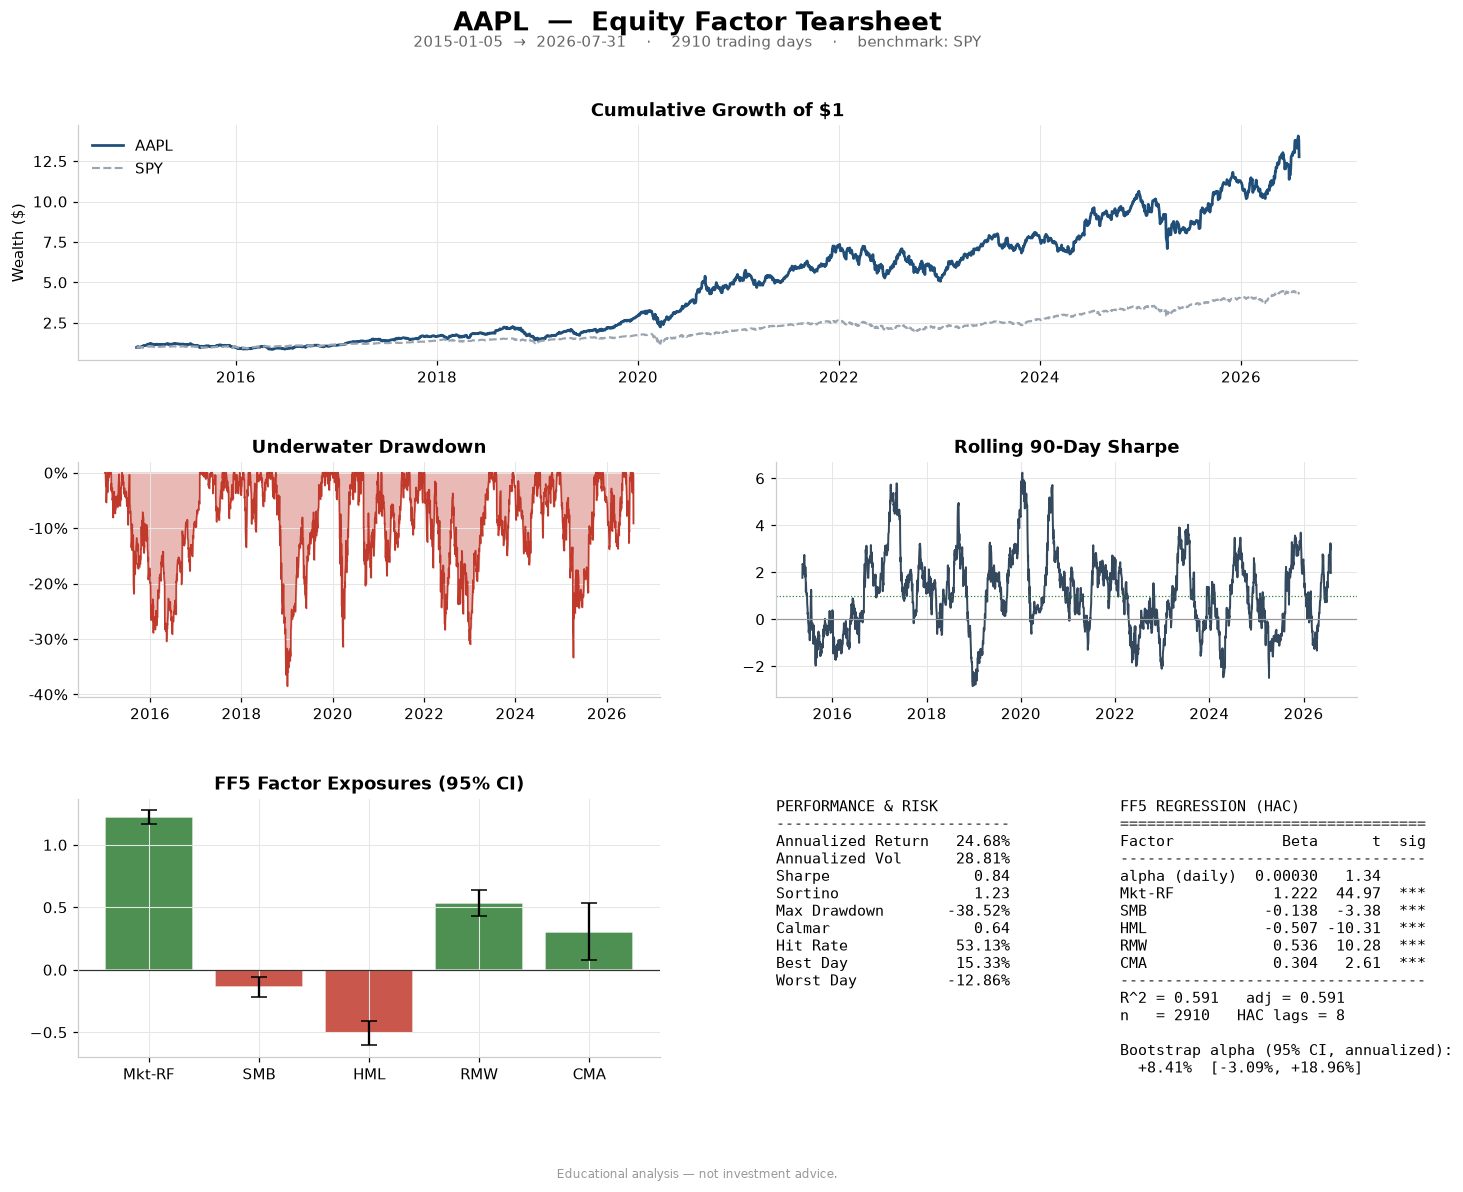


INTERPRETATION — AAPL
ALPHA (skill vs. cheap beta)
  FF5 annualized alpha: +7.53%  (HAC t = +1.34)
  Bootstrap 95% CI:     [-3.09%, +18.96%]
  → Alpha is not distinguishable from zero. The return stream is
    replicable with cheap factor exposure.

FACTOR FIT
  FF5 R^2 = 0.59   (FF3 R^2 = 0.56)
  → Meaningful stock-specific behaviour.

DOMINANT TILT
  Largest exposure is Mkt-RF (+1.22): loads on market.

DRAWDOWN
  Worst peak-to-trough loss was -38.5%.


In [110]:
result = generate_tearsheet("AAPL")

In [111]:
comparison = compare(["AAPL", "KO", "ARKK", "BRK-B"])

,Ann.Return,Ann.Vol,Sharpe,Max DD,Calmar,FF5 Alpha (ann.),Alpha t,Mkt beta,R^2
AAPL,24.68%,28.81%,0.84,-38.52%,0.64,+7.53%,+1.34,1.22,0.59
KO,9.92%,17.94%,0.50,-36.99%,0.27,+0.66%,+0.15,0.59,0.36
ARKK,12.54%,38.51%,0.45,-80.91%,0.16,+4.54%,+1.02,1.28,0.81
BRK-B,11.26%,19.09%,0.55,-29.57%,0.38,-0.22%,-0.07,0.83,0.68


## 12. What the output actually says

**AAPL, 2015 to mid-2026.** 24.68% a year at 28.81% volatility, Sharpe 0.84.
The five-factor regression puts annualized alpha at +7.53%, which looks like
skill until you read the uncertainty on it: HAC t = 1.34, bootstrap CI from
−3.09% to +18.96%. Two different methods, one parametric and one not, agree
the estimate is indistinguishable from zero. What the regression does find is
a market beta of 1.22, a quality tilt (RMW +0.54) and a strong growth tilt
(HML −0.51), all at t-stats above 10. The return is real. The evidence that
it came from anything other than those exposures is not.

**Four names, no alpha.** Alpha t-stats across AAPL, KO, ARKK and BRK-B are
+1.34, +0.15, +1.02 and −0.07. Not one clears 1.96. Across a mega-cap growth
stock, a defensive staple, a high-beta growth ETF and a value conglomerate,
eleven years of daily data produces no statistically detectable skill. That is
the expected result and it is the point of running the test rather than
reporting the point estimate.

**ARKK is the risk lesson.** 12.54% a year against BRK-B's 11.26%, which reads
as a tie on the growth chart. The volatility is 38.51% against 19.09% and the
worst drawdown is −80.91% against −29.57%. Calmar 0.16 against 0.38. An
allocator holding ARKK through 2021 to 2022 lost four fifths of the position
for a return the conglomerate matched.

**R² needs context.** ARKK's 0.81 says most of its variation is factor
exposure, which for a fund charging active fees is the closet-indexing
question. AAPL's 0.59 says nothing similar, because a single stock moving with
the market is not paying anyone a fee.

---

### Limitations

Factor loadings are full-sample averages. Real exposures drift, and rolling
betas would show that.

Ken French publishes with a lag, so the window ends several weeks short of
today.

`auto_adjust` handles splits and dividends, but any analysis of names that
still exist is survivorship biased.

Alpha is annualized linearly (×252) rather than compounded. At these
magnitudes the difference is about 0.2 percentage points.

No correction for multiple testing. Screen enough names and some will show
significant alpha by chance.